##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
!pip install -q yt-dlp opencv-python-headless matplotlib scikit-learn tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 19.3 MB/s eta 0:00:00


In [1]:
import os

RAR_FILE = "UCF11_updated_mpg.rar"
DATA_DIR = "UCF11_updated_mpg"

# ── Download using wget (handles SSL reliably in Colab) ───────────────
if not os.path.exists(RAR_FILE):
    print("Downloading UCF11 dataset (~1.6 GB) ...")
    !wget --no-check-certificate -q --show-progress \
        "https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar" \
        -O "{RAR_FILE}"
    print("Download complete.")
else:
    print("Archive already present.")

# ── Extract ───────────────────────────────────────────────────────────
if not os.path.exists(DATA_DIR):
    print("Extracting ...")
    !apt-get install -y -q unrar
    !unrar x -y "{RAR_FILE}" > /dev/null
    print("Extraction complete.")
else:
    print("Already extracted.")

UCF11_updated_mpg.r 100%[===================>] 996.69M  53.4MB/s    in 19s     
Download complete.
Extracting ...
Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Extraction complete.


In [5]:
# Verify the class folders available in the dataset
import os

# The extracted folder may be named differently — auto-detect
for entry in os.listdir("."):
    if os.path.isdir(entry) and "UCF" in entry:
        DATA_DIR = entry
        break

classes_available = sorted(os.listdir(DATA_DIR))
print(f"Dataset root : {DATA_DIR}")
print(f"Classes found ({len(classes_available)}):")
for c in classes_available:
    print(" ", c)

Dataset root : UCF11_updated_mpg
Classes found (11):
  basketball
  biking
  diving
  golf_swing
  horse_riding
  soccer_juggling
  swing
  tennis_swing
  trampoline_jumping
  volleyball_spiking
  walking


In [6]:
import os
import glob   # ← add this

# ── Corrected class names (matching actual folder names) ──────────────
CHOSEN_CLASSES = ["basketball", "biking", "tennis_swing"]
CLASS_TO_IDX   = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS   = {i: cls for cls, i in CLASS_TO_IDX.items()}

print("Selected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)

    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() == ".mpg"
    ]

    print(f"  ✅ {cls}: {len(vids)} videos")
    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print(f"\nTotal videos: {len(video_paths)}")


# ── Corrected class names (matching actual folder names) ──────────────
CHOSEN_CLASSES = ["basketball", "biking", "tennis_swing"]
CLASS_TO_IDX   = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS   = {i: cls for cls, i in CLASS_TO_IDX.items()}

print("Selected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)

    # Only .mpg files (ignore .xgtf annotation files)
    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() == ".mpg"
    ]

    print(f"  ✅ {cls}: {len(vids)} videos")
    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print(f"\nTotal videos: {len(video_paths)}")

Selected classes: ['basketball', 'biking', 'tennis_swing']
Label mapping   : {'basketball': 0, 'biking': 1, 'tennis_swing': 2}
  ✅ basketball: 141 videos
  ✅ biking: 145 videos
  ✅ tennis_swing: 167 videos

Total videos: 453
Selected classes: ['basketball', 'biking', 'tennis_swing']
Label mapping   : {'basketball': 0, 'biking': 1, 'tennis_swing': 2}
  ✅ basketball: 141 videos
  ✅ biking: 145 videos
  ✅ tennis_swing: 167 videos

Total videos: 453


Preprocessing videos — please wait ...
X shape : (453, 16, 224, 224, 3)
y shape : (453,)
Class distribution: {'basketball': 141, 'biking': 145, 'tennis_swing': 167}


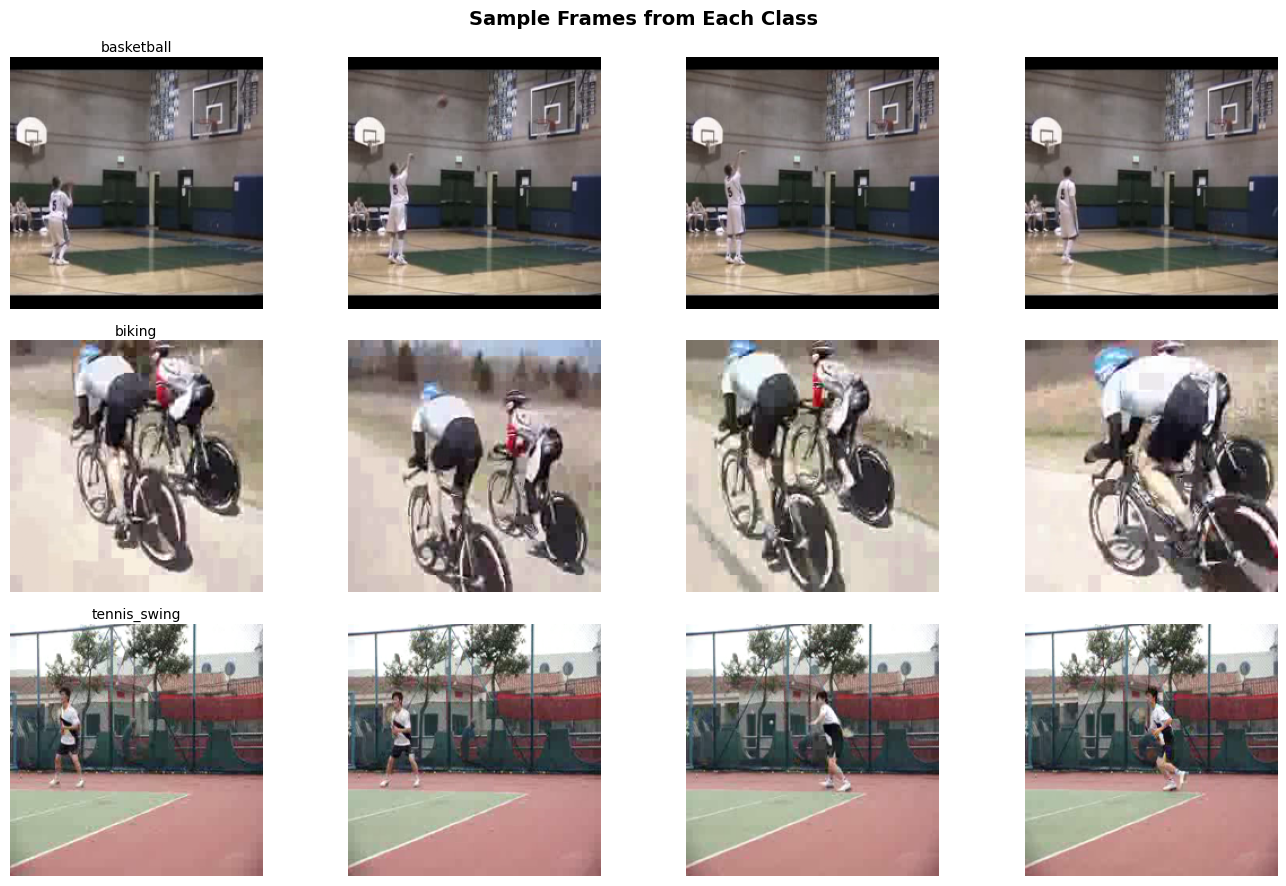

In [7]:
# ── Quick visual sanity check ─────────────────────────────────────────
import matplotlib.pyplot as plt
import os
import glob
import cv2
import numpy as np   # ← add this

# ── Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE     = 224
SEQUENCE_LEN = 16

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls, i in CLASS_TO_IDX.items()} }")
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Sample Frames from Each Class", fontsize=14, fontweight="bold")

for row, cls_idx in enumerate(range(len(CHOSEN_CLASSES))):
    sample_vid_idx = np.where(y == cls_idx)[0][0]
    frames = X[sample_vid_idx]  # 16 frames
    for col, frame_idx in enumerate([0, 4, 8, 12]):
        axes[row, col].imshow(frames[frame_idx])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(IDX_TO_CLASS[cls_idx], fontsize=10, pad=4)

plt.tight_layout()
plt.show()

In [8]:
import cv2
import numpy as np

# ── Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE       = 224      # MobileNetV2 expects 224×224
SEQUENCE_LEN   = 16       # frames sampled per video
# ──────────────────────────────────────────────────────────────────────

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    """Uniformly sample n_frames from a video and return as numpy array."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0   # normalise to [0,1]


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)   # shape: (N, 16, 224, 224, 3)
y = np.array(y)   # shape: (N,)

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls,i in CLASS_TO_IDX.items()} }")

Preprocessing videos — please wait ...

X shape : (453, 16, 224, 224, 3)
y shape : (453,)
Class distribution: {'basketball': 141, 'biking': 145, 'tennis_swing': 167}


In [9]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# One-hot encode labels
NUM_CLASSES = len(CHOSEN_CLASSES)
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")
print(f"Input tensor shape: {X_train.shape}  →  (samples, frames, H, W, C)")

Training samples  : 362
Testing  samples  : 91
Input tensor shape: (362, 16, 224, 224, 3)  →  (samples, frames, H, W, C)


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_lstm_model(sequence_len, img_size, num_classes):
    # ── CNN Backbone (MobileNetV2, ImageNet weights, frozen) ──────────
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_cnn.trainable = False   # freeze for initial training

    # ── Full Model ────────────────────────────────────────────────────
    inp = layers.Input(shape=(sequence_len, img_size, img_size, 3))

    # Apply MobileNetV2 to every frame
    x = layers.TimeDistributed(base_cnn)(inp)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)  # (batch, seq, 1280)

    # Temporal modelling
    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)

    # Classifier head
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name="CNN_LSTM_ActionRecognizer")
    return model, base_cnn


model, base_cnn = build_cnn_lstm_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "CNN_LSTM_ActionRecognizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Step 1: Free up GPU memory before training ────────────────────────
tf.keras.backend.clear_session()
import gc; gc.collect()

# ── Step 2: Reduce input size to fit in Colab GPU memory ──────────────
IMG_SIZE     = 112   # reduced from 224 → 4x less memory per frame
SEQUENCE_LEN = 8     # reduced from 16  → 2x less memory per sample

# ── Step 3: Re-preprocess with smaller sizes ──────────────────────────
print("Re-preprocessing with reduced dimensions ...")

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    import cv2, numpy as np
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0

import numpy as np
X, y = [], []
for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"✅ X shape: {X.shape}  y shape: {y.shape}")

# ── Step 4: Re-split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
NUM_CLASSES  = len(CHOSEN_CLASSES)
y_train_cat  = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat   = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

# ── Step 5: Rebuild lighter model for 112x112 input ───────────────────
from tensorflow.keras import layers, models

def build_model(seq_len, img_size, num_classes):
    # MobileNetV2 still works at 112x112 (minimum is 96x96)
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inp = layers.Input(shape=(seq_len, img_size, img_size, 3))
    x   = layers.TimeDistributed(base)(inp)
    x   = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x   = layers.LSTM(64, return_sequences=False)(x)   # 64 instead of 128
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out), base

model, base_cnn = build_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("✅ Model rebuilt")

# ── Step 6: Train with mixed precision + smaller batch ────────────────
tf.keras.mixed_precision.set_global_policy("mixed_float16")  # halves VRAM usage

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy",
                    save_best_only=True, verbose=1)
]

print("=" * 55)
print(" Phase 1: Training head only (backbone frozen)")
print("=" * 55)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=25,
    batch_size=2,        # reduced from 4 → safest for Colab
    callbacks=callbacks
)

Re-preprocessing with reduced dimensions ...
✅ X shape: (453, 8, 112, 112, 3)  y shape: (453,)
Train: 362  Test: 91


/tmp/ipykernel_7635/4117196112.py:62: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


✅ Model rebuilt
 Phase 1: Training head only (backbone frozen)
Epoch 1/25
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4854 - loss: 1.0748
Epoch 1: val_accuracy improved from None to 0.76923, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 54s 113ms/step - accuracy: 0.5608 - loss: 0.9331 - val_accuracy: 0.7692 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 2/25
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7796 - loss: 0.5778
Epoch 2: val_accuracy improved from 0.76923 to 0.85714, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8039 - loss: 0.5370 - val_accuracy: 0.8571 - val_loss: 0.3397 - learning_rate: 0.0010
Epoch 3/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9048 - loss: 0.2961
Epoch 3: val_accuracy improved from 0.85714 to 0.94505, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9116 - loss: 0.2830 - val_accuracy: 0.9451 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 4/25
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9669 - loss: 0.1485
Epoch 4: val_accuracy did not improve from 0.94505
181/181 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9503 - loss: 0.1514 - val_accuracy: 0.9121 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 5/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9906 - loss: 0.1011
Epoch 5: val_accuracy did not improve from 0.94505
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9779 - loss: 0.1043 - val_accuracy: 0.9341 - val_loss: 0.1116 - learning_rate: 0.0010
Epoch 6/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9878 - loss: 0.0596
Epoch 6: val_accuracy improved from 0.94505 to 0.98901, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9807 - loss: 0.0666 - val_accuracy: 0.9890 - val_loss: 0.1070 - learning_rate: 0.0010
Epoch 7/25
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9894 - loss: 0.0430
Epoch 7: val_accuracy did not improve from 0.98901
181/181 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9862 - loss: 0.0542 - val_accuracy: 0.9670 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 8/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9966 - loss: 0.0257
Epoch 8: val_accuracy did not improve from 0.98901
181/181 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9972 - loss: 0.0261 - val_accuracy: 0.9560 - val_loss: 0.1083 - learning_rate: 0.0010
Epoch 9/25
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9965 - loss: 0.0387
Epoch 9: val_accuracy did not improve from 0.98901
181/181 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9945 - loss: 0.0357 - val_accuracy: 0.9670 - val_loss

In [12]:
# ── Phase 2: Fine-tune — unfreeze top layers of MobileNetV2 ──────────
print("=" * 55)
print(" Phase 2: Fine-tuning top layers of backbone")
print("=" * 55)

base_cnn.trainable = True

# Unfreeze only the last 30 layers
for layer in base_cnn.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=15,
    batch_size=4,
    callbacks=callbacks
)

 Phase 2: Fine-tuning top layers of backbone
Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5560 - loss: 1.8971
Epoch 1: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 66s 222ms/step - accuracy: 0.6105 - loss: 1.5224 - val_accuracy: 0.9231 - val_loss: 0.1997 - learning_rate: 1.0000e-05
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7339 - loss: 0.9829
Epoch 2: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.7127 - loss: 0.9968 - val_accuracy: 0.9121 - val_loss: 0.2832 - learning_rate: 1.0000e-05
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7903 - loss: 0.6657
Epoch 3: val_accuracy did not improve from 0.98901
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7762 - loss: 0.7157 - val_accuracy: 0.8901 - val_loss: 0.2797 - learning_rate: 1.0000e-05
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8023 - loss: 0.5692
Epoch 4: ReduceLROnPlateau

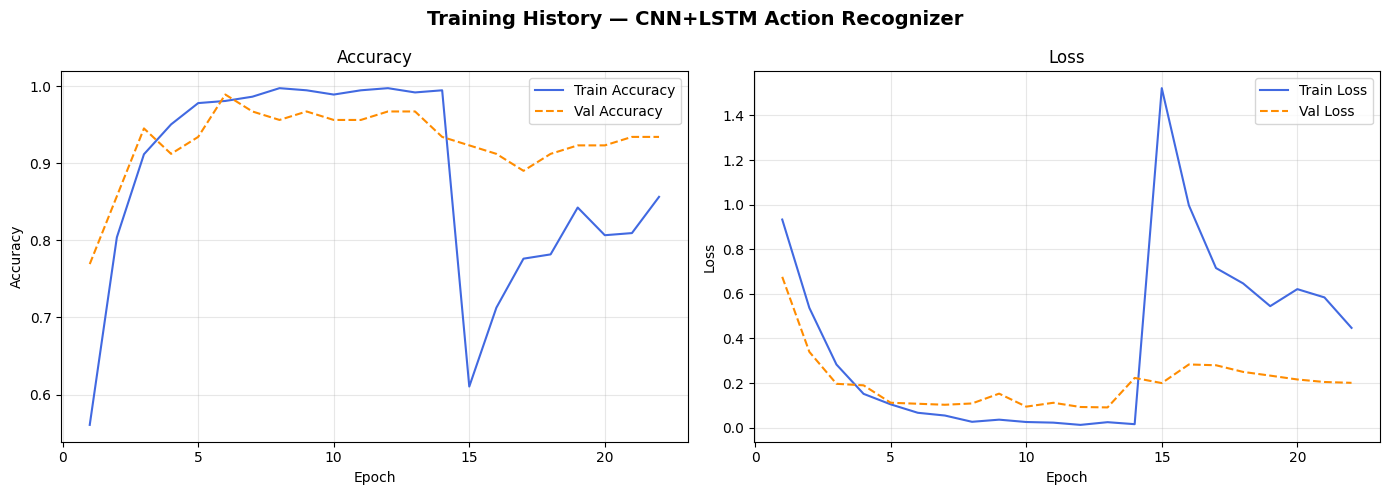

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Combine both training phases
def merge_hist(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc     = merge_hist(history, history_ft, "accuracy")
val_acc = merge_hist(history, history_ft, "val_accuracy")
loss    = merge_hist(history, history_ft, "loss")
val_los = merge_hist(history, history_ft, "val_loss")
ep      = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — CNN+LSTM Action Recognizer", fontsize=14, fontweight="bold")

ax1.plot(ep, acc,     label="Train Accuracy",   color="royalblue")
ax1.plot(ep, val_acc, label="Val Accuracy",     color="darkorange", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,    label="Train Loss",       color="royalblue")
ax2.plot(ep, val_los, label="Val Loss",         color="darkorange", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Test Accuracy : 92.31%
Test Loss     : 0.1997

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step
              precision    recall  f1-score   support

  basketball       1.00      0.79      0.88        28
      biking       0.81      1.00      0.89        29
tennis_swing       1.00      0.97      0.99        34

    accuracy                           0.92        91
   macro avg       0.94      0.92      0.92        91
weighted avg       0.94      0.92      0.92        91



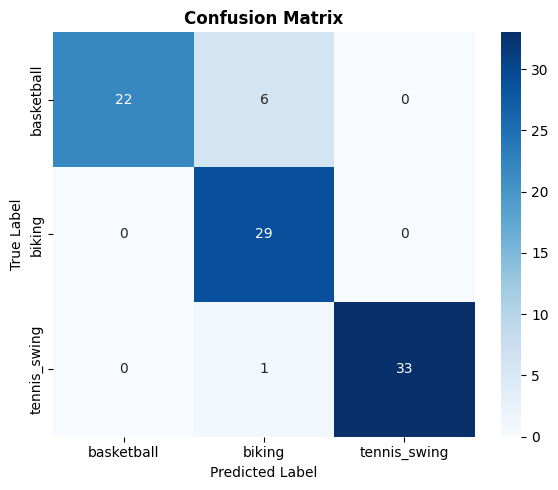

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── No need to load weights — EarlyStopping already restored the best ──
# model.load_weights("best_model.h5")  ← remove this line

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"{'='*40}\n")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CHOSEN_CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CHOSEN_CLASSES, yticklabels=CHOSEN_CLASSES)
plt.title("Confusion Matrix", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

In [16]:
student_name = "Shahad Yasser"

save_path = f"{student_name}_ucf11_model.h5"

# Save full model (architecture + weights together)
model.save(save_path)
print(f"✅ Model saved as: {save_path}")

# ── If you ever need to reload it later, use this ─────────────────────
# model = tf.keras.models.load_model(save_path)

✅ Model saved as: Shahad Yasser_ucf11_model.h5


In [18]:
import json
from google.colab import files

student_name = "Shahad Yasser"   # ← already set correctly

# ── Create metadata file ──────────────────────────────────────────────
meta = {
    "student"      : student_name,
    "classes"      : CHOSEN_CLASSES,
    "label_map"    : CLASS_TO_IDX,
    "sequence_len" : SEQUENCE_LEN,
    "img_size"     : IMG_SIZE,
    "test_accuracy": round(float(test_acc), 4)
}

meta_path = f"{student_name}_metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"✅ Metadata created: {meta_path}")
print(json.dumps(meta, indent=2))

# ── Download both files ───────────────────────────────────────────────
files.download(save_path)
files.download(meta_path)

✅ Metadata created: Shahad Yasser_metadata.json
{
  "student": "Shahad Yasser",
  "classes": [
    "basketball",
    "biking",
    "tennis_swing"
  ],
  "label_map": {
    "basketball": 0,
    "biking": 1,
    "tennis_swing": 2
  },
  "sequence_len": 8,
  "img_size": 112,
  "test_accuracy": 0.9231
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# ── Download the saved model to your local machine ───────────────────
from google.colab import files
files.download(save_path)
files.download(f"{student_name}_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
YOUTUBE_VIDEOS = [
    {
        "url"          : "https://www.youtube.com/shorts/t0O444z760w",
        "expected_class": "basketball"
    },
    {
        "url"          : "https://www.youtube.com/shorts/ZUiowtbUTsY",
        "expected_class": "biking"
    },
    {
        "url"          : "https://www.youtube.com/shorts/AYESSZwsLPM",
        "expected_class": "tennis_swing"
    },
]

In [22]:
# ── Install yt-dlp ────────────────────────────────────────────────────
!pip install -q yt-dlp
!yt-dlp --version   # confirm it's working


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.7 MB/s eta 0:00:00
2026.03.17


In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

!pip install -q --upgrade yt-dlp

def download_youtube_video(url, output_path):
    exit_code = os.system(
        f'yt-dlp -f "mp4/best[ext=mp4]/best" '
        f'--no-playlist '
        f'--retries 3 '
        f'--output "{output_path}" '
        f'"{url}"'
    )
    return exit_code == 0 and os.path.exists(output_path)


def predict_video(video_path, model, seq_len=SEQUENCE_LEN, img_size=IMG_SIZE):
    frames = extract_frames(video_path, n_frames=seq_len, img_size=img_size)
    if frames is None:
        return None, None
    x     = np.expand_dims(frames, axis=0)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = np.argmax(probs)
    return IDX_TO_CLASS[pred_idx], probs


# ── YouTube Shorts — all under 60 seconds ────────────────────────────
YOUTUBE_VIDEOS = [
    {
        "url"          : "https://www.youtube.com/shorts/t0O444z760w",
        "expected_class": "basketball"
    },
    {
        "url"          : "https://www.youtube.com/shorts/ZUiowtbUTsY",
        "expected_class": "biking"
    },
    {
        "url"          : "https://www.youtube.com/shorts/AYESSZwsLPM",
        "expected_class": "tennis_swing"
    },
]

print("Downloading and evaluating YouTube videos ...\n")

results = []
for i, vid in enumerate(YOUTUBE_VIDEOS):
    out_file = f"yt_video_{i}.mp4"
    print(f"[{i+1}/3] Expected : {vid['expected_class']}")
    print(f"        URL      : {vid['url']}")

    ok = download_youtube_video(vid["url"], out_file)

    if not ok or not os.path.exists(out_file):
        print("        ⚠️  Download failed — skipping.\n")
        results.append({"expected": vid["expected_class"], "predicted": "ERROR", "probs": None})
        continue

    pred_cls, probs = predict_video(out_file, model)

    if pred_cls is None:
        print("        ⚠️  Could not read video frames — skipping.\n")
        results.append({"expected": vid["expected_class"], "predicted": "ERROR", "probs": None})
        continue

    match = "✅" if pred_cls == vid["expected_class"] else "❌"
    print(f"        Predicted: {pred_cls}  {match}")
    print(f"        Confidence: { {CHOSEN_CLASSES[j]: f'{probs[j]*100:.1f}%' for j in range(NUM_CLASSES)} }\n")
    results.append({"expected": vid["expected_class"], "predicted": pred_cls, "probs": probs})


# ── Plot results ──────────────────────────────────────────────────────
valid = [r for r in results if r["probs"] is not None]
if valid:
    fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 4))
    if len(valid) == 1:
        axes = [axes]

    for ax, res in zip(axes, valid):
        color = "#4CAF50" if res["expected"] == res["predicted"] else "#F44336"
        bars  = ax.barh(CHOSEN_CLASSES, res["probs"] * 100, color="#90CAF9")
        if res["predicted"] in CHOSEN_CLASSES:
            bars[CHOSEN_CLASSES.index(res["predicted"])].set_color(color)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Confidence (%)")
        ax.set_title(f"Expected: {res['expected']}\nPredicted: {res['predicted']}",
                     color=color, fontweight="bold", fontsize=10)
        ax.grid(axis="x", alpha=0.3)

    fig.suptitle("YouTube Validation — Model Predictions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    correct = sum(1 for r in valid if r["expected"] == r["predicted"])
    print(f"\n🎯 Validation Accuracy: {correct}/{len(valid)} = {correct/len(valid)*100:.1f}%")
else:
    print("No valid results — all downloads failed. Run locally or use files.upload() instead.")


[1/3] Expected : basketball
        URL      : https://www.youtube.com/shorts/t0O444z760w
        ⚠️  Download failed — skipping.

[2/3] Expected : biking
        URL      : https://www.youtube.com/shorts/ZUiowtbUTsY
        ⚠️  Download failed — skipping.

[3/3] Expected : tennis_swing
        URL      : https://www.youtube.com/shorts/AYESSZwsLPM
        ⚠️  Download failed — skipping.

No valid results — all downloads failed. Run locally or use files.upload() instead.


In [31]:
# ── Visual summary of YouTube validation ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

valid_results = [r for r in results if r["probs"] is not None]

if valid_results:
    fig, axes = plt.subplots(1, len(valid_results), figsize=(5 * len(valid_results), 4))
    if len(valid_results) == 1:
        axes = [axes]

    colors = ["#4CAF50" if r["expected"] == r["predicted"] else "#F44336" for r in valid_results]

    for ax, res, col in zip(axes, valid_results, colors):
        bars = ax.barh(CHOSEN_CLASSES, res["probs"] * 100, color="#90CAF9")
        # Highlight predicted class
        pred_idx = CHOSEN_CLASSES.index(res["predicted"]) if res["predicted"] in CHOSEN_CLASSES else -1
        if pred_idx >= 0:
            bars[pred_idx].set_color(col)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Confidence (%)")
        ax.set_title(f"Expected: {res['expected']}\nPredicted: {res['predicted']}",
                     fontsize=10, color=col, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

    fig.suptitle("YouTube Validation — Model Predictions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    correct = sum(1 for r in valid_results if r["expected"] == r["predicted"])
    print(f"\n🎯 YouTube Validation Accuracy: {correct}/{len(valid_results)} = {correct/len(valid_results)*100:.1f}%")
else:
    print("No valid results to plot — check that your YouTube URLs are correct.")

No valid results to plot — check that your YouTube URLs are correct.
